# Inspect emulators results

In [1]:
root = '/data/emilio/emu_like'

spectrum_type = 'cl'
spectrum = 'cl_TT_lensed'
dataset_ranges = ['thin', 'std', 'ext']

paths_emu = [
    'lcdm/train/test_cl_1',
    'lcdm/train/test_cl_2',
    # 'lcdm/train/test_cl_3',
    # 'lcdm/train/test_cl_4',
    # 'lcdm/train/test_cl_5',
]


## Init

### Imports and definitions

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2025-10-20 15:08:22.518500: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-20 15:08:22.519036: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-20 15:08:22.580821: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-20 15:08:24.007317: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [3]:
class EmuData(object):

    def __init__(self, path_emu, root=root):
        self.name = path_emu
        self.emu = FFNNEmu()
        self.emu.load(os.path.join(root, path_emu), still_training=False)
        self.abs_diff = None
        self.rel_diff = None
        self.mean_abs_diff = None
        self.mean_rel_diff = None
        pass

    def _scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def _scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def _inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def _inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def _pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def _pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def _inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def _inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y_emu(self, x, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        From the emulator we get y that are potentially scaled and PCA
        applied. However, it is possible that just one or none of them
        are used. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot keep scaled units: y is already unscaled.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        # 1) Adjust x
        # Adjust dimensions x array
        if x.ndim == 1:
            x = x[np.newaxis, :]
        # Scale x
        if self.emu.x_scaler is not None:
            x = self._scale_x(x)
        # PCA x
        if self.emu.x_pca is not None:
            x = self._pca_x(x)

        # 2) Emulate y
        result = self.emu.model(x, training=False).numpy()

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if has_pca and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove scaling
        if has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_y_data(self, y, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        Postprocess the data to add/remove scaling and PCA. It works to provide
        a compatible output of get_y_emu. Input data are assumed to not be scaled and
        without PCA applied. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot use scaled units: emulator has no scaling transform.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        result = y

        # 1) Scale
        if want_scaling or (want_pca_selection and has_scaling):
            result = self._scale_y(result)

        # 2) PCA
        if want_pca or want_pca_selection:
            result = self._pca_y(result)

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if want_pca_selection and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove Scale
        if want_pca_selection and has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_abs_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        """
        Get the absolute difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.diff = y_emu - y_data
        return self.diff
    
    def get_rel_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        """
        Get the relative difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.diff = y_emu/y_data -1.
        return self.diff

    def get_mean_abs_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        if x_emu is not None and y_data is not None:
            self.abs_diff = self.get_abs_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data)

        self.mean_abs_diff = np.mean(self.abs_diff**2., axis=1)
        return self.mean_abs_diff
    
    def get_mean_rel_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        if x_emu is not None and y_data is not None:
            self.rel_diff = self.get_rel_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data)

        self.mean_rel_diff = np.mean(self.rel_diff**2., axis=1)
        return self.mean_rel_diff

    def get_sorting_idxs_abs(self):
        if self.mean_abs_diff is None:
            raise Exception('Calculate mean_abs_diff first')
        return self.mean_abs_diff.argsort()[::-1]

    def get_sorting_idxs_rel(self):
        if self.mean_rel_diff is None:
            raise Exception('Calculate mean_rel_diff first')
        return self.mean_rel_diff.argsort()[::-1]

### Load data and emulators

In [4]:
# Load data
x_data = {}
y_data = {}
for dr in dataset_ranges:
    path_dataset = os.path.join(root, 'lcdm/sample/{}_100_{}.fits'.format(spectrum_type, dr))
    dataset = io.FitsFile(path_dataset)
    x_data[dr] = dataset.get_data('x_data')
    y_data[dr] = dataset.get_data(spectrum)

In [5]:
# Load emulators
emudata = {}
for path in paths_emu:
    emudata[path] = EmuData(path, root=root)

2025-10-20 15:08:30.466310: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Plot PCA modes reconstruction

In [6]:
tot_n_pca = 64
n_ell = 2999

mean_abs_rel_diff_per_ell = {}
mean_abs_rel_diff = {}

for ndt, dt in enumerate(dataset_ranges):
    mean_abs_rel_diff_per_ell[dt] = np.zeros((tot_n_pca, n_ell))
    for n_pca in range(tot_n_pca):
        y_pca = emudata[paths_emu[0]].get_y_data(
            y_data[dt],
            want_scaling=False,
            want_pca=False,
            select_pca_modes=range(n_pca))
        rel_diff = y_pca/y_data[dt] - 1.
        mean_abs_rel_diff_per_ell[dt][n_pca] = np.mean(np.abs(rel_diff), axis=0)
    mean_abs_rel_diff[dt] = np.mean(mean_abs_rel_diff_per_ell[dt], axis=1)

KeyboardInterrupt: 

In [8]:
tot_n_pca = 64
n_ell = 2999

mean_abs_rel_diff_per_ell = {}
mean_abs_rel_diff = {}

for ndt, dt in enumerate(dataset_ranges):
    mean_abs_rel_diff_per_ell[dt] = np.zeros((tot_n_pca, n_ell))
    y_pca = emudata[paths_emu[0]].get_y_data(
        y_data[dt],
        want_scaling=False,
        want_pca=False,
        select_pca_modes=range(tot_n_pca))
    rel_diff = y_pca/y_data[dt] - 1.
    mean_abs_rel_diff_per_ell[dt][tot_n_pca-1] = np.mean(np.abs(rel_diff), axis=0)
    mean_abs_rel_diff[dt] = np.mean(mean_abs_rel_diff_per_ell[dt], axis=1)

In [ ]:
fig, axs = plt.subplots(1, len(dataset_ranges),
                        figsize=(6 * len(dataset_ranges), 4),
                        squeeze=False)

cmap = plt.cm.spring
norm = plt.Normalize(vmin=0, vmax=tot_n_pca - 1)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed for the colorbar

for ndt, dt in enumerate(dataset_ranges):
    axs[0, ndt].set_title(dt)
    data = mean_abs_rel_diff_per_ell[dt]

    colors = cmap(norm(np.arange(data.shape[0])))
    for mode_idx, color in enumerate(colors):
        axs[0, ndt].plot(data[mode_idx], color=color, alpha=0.9)

    axs[0, ndt].set_yscale('log')

fig.colorbar(sm, ax=axs.ravel().tolist(),
             label='PCA mode index',
             fraction=0.03, pad=0.06)


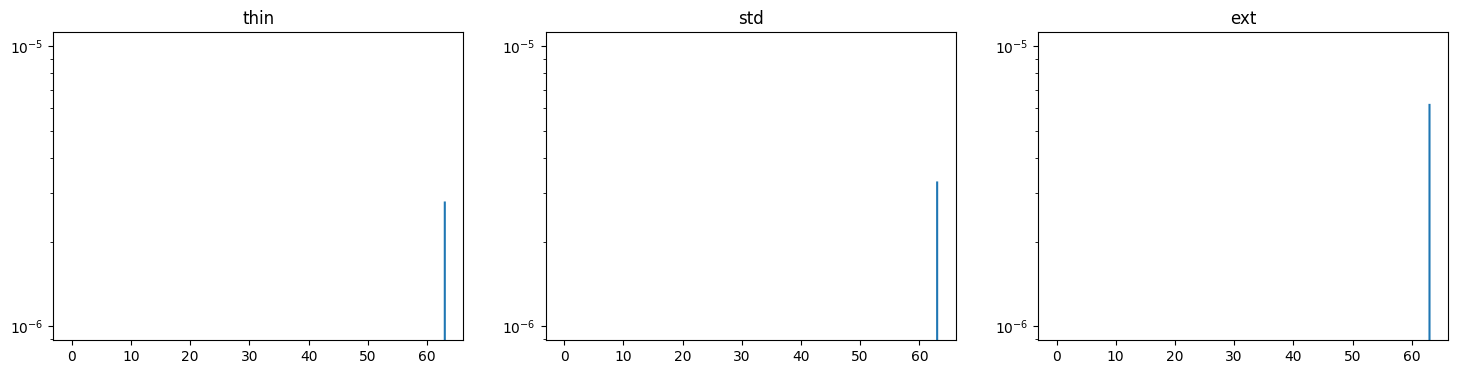

In [10]:
fig, axs = plt.subplots(1, len(dataset_ranges),
                        figsize=(6 * len(dataset_ranges), 4),
                        squeeze=False)

for ndt, dt in enumerate(dataset_ranges):
    axs[0, ndt].set_title(dt)
    data = mean_abs_rel_diff[dt]

    axs[0, ndt].plot(data)

    axs[0, ndt].set_yscale('log')


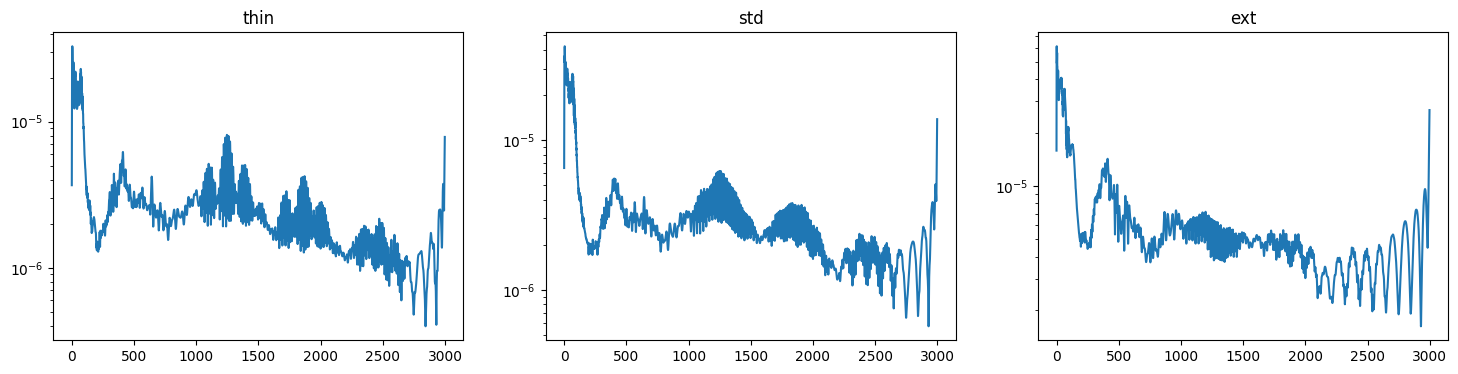

In [9]:
fig, axs = plt.subplots(1, len(dataset_ranges),
                        figsize=(6 * len(dataset_ranges), 4),
                        squeeze=False)

for ndt, dt in enumerate(dataset_ranges):
    axs[0, ndt].set_title(dt)
    data = mean_abs_rel_diff_per_ell[dt][-1]

    axs[0, ndt].plot(data)

    axs[0, ndt].set_yscale('log')


In [ ]:
mean_abs_rel_diff_per_ell['thin'][-1]

## Histograms

In [ ]:
# Create figure
fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False)
fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

# Plot data in each subplot
for npath, path in enumerate(paths_emu):
    for ndt, dt in enumerate(dataset_ranges):
        mean_diff = emudata[path].get_rel_mean_diff(
            x_emu=x_data[dt],
            y_data=y_data[dt],
            want_scaling=False,
            want_pca=False,
            select_pca_modes_emu=None,
            select_pca_modes_data=None)

        axs[npath, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[npath, ndt].set_title('dataset {} - emulator {}'.format(dt, path), fontsize=18)
        axs[npath, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Create figure
fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False)
fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

# Plot data in each subplot
for npath, path in enumerate(paths_emu):
    for ndt, dt in enumerate(dataset_ranges):
        mean_diff = emudata[path].get_mean_diff(
            x_emu=x_data[dt],
            y_data=y_data[dt],
            want_scaling=True,
            want_pca=True,
            select_pca_modes_emu=None,
            select_pca_modes_data=None)

        axs[npath, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[npath, ndt].set_title('dataset {} - emulator {}'.format(dt, path), fontsize=18)
        axs[npath, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
def eval_pca_mse(emudata_obj, x, y):
    # Feed x through the network exactly as during training
    y_pred_pca = emudata_obj.get_y_emu(
        x,
        want_scaling=True,   # keep the scaler and PCA transforms active
        want_pca=True
    )
    y_true_pca = emudata_obj.get_y_data(
        y,
        want_scaling=True,
        want_pca=True
    )
    err = y_pred_pca - y_true_pca
    return np.mean(err**2)

metrics = {}
for key, obj in emudata.items():
    # mse_train = eval_pca_mse(obj, obj.data.x_train, obj.data.y_train)
    # mse_val = eval_pca_mse(obj, obj.data.x_test, obj.data.y_test)
    # metrics[key] = dict(train=mse_train, val=mse_val)
    mse_thin = eval_pca_mse(obj, x_data['thin'], y_data['thin'])
    mse_std = eval_pca_mse(obj, x_data['std'], y_data['std'])
    mse_ext = eval_pca_mse(obj, x_data['ext'], y_data['ext'])
    metrics[key] = dict(thin=mse_thin, std=mse_std, ext=mse_ext)

metrics
